In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])


In [12]:
losses = []
accuracies = []


In [3]:
train_dataset = datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)


100%|██████████| 26.4M/26.4M [00:01<00:00, 15.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 309kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.58MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 17.9MB/s]


In [10]:
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]


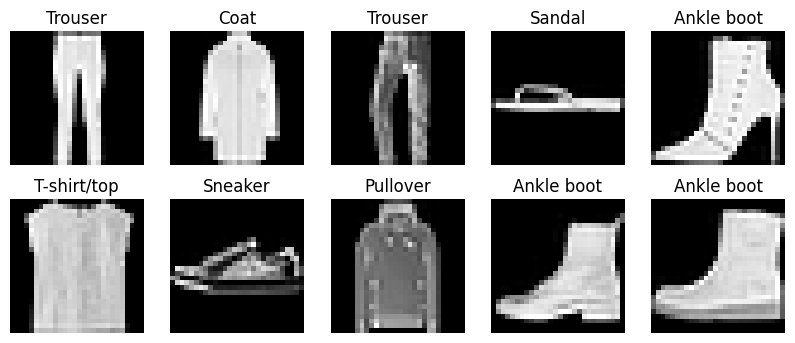

In [11]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.title(class_names[labels[i]])
    plt.axis('off')

plt.show()


In [4]:
class DeepFeedForwardNN(nn.Module):
    def __init__(self):
        super(DeepFeedForwardNN, self).__init__()
        self.fc1 = nn.Linear(784, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 128)
        self.fc4 = nn.Linear(128, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = x.view(x.size(0), -1)  # Flatten image
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.fc4(x)  # Linear output
        return x


In [5]:
model = DeepFeedForwardNN()


In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [13]:

epochs = 10

for epoch in range(epochs):
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total


    losses.append(running_loss / len(train_loader))
    accuracies.append(accuracy)

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss:.4f}, Accuracy: {accuracy:.2f}%")


Epoch [1/10], Loss: 197.4406, Accuracy: 92.07%
Epoch [2/10], Loss: 186.7944, Accuracy: 92.41%
Epoch [3/10], Loss: 178.3164, Accuracy: 92.72%
Epoch [4/10], Loss: 168.5678, Accuracy: 93.21%
Epoch [5/10], Loss: 161.0295, Accuracy: 93.46%
Epoch [6/10], Loss: 152.8804, Accuracy: 93.76%
Epoch [7/10], Loss: 147.1970, Accuracy: 94.15%
Epoch [8/10], Loss: 139.6087, Accuracy: 94.35%
Epoch [9/10], Loss: 135.4456, Accuracy: 94.49%
Epoch [10/10], Loss: 130.3331, Accuracy: 94.70%


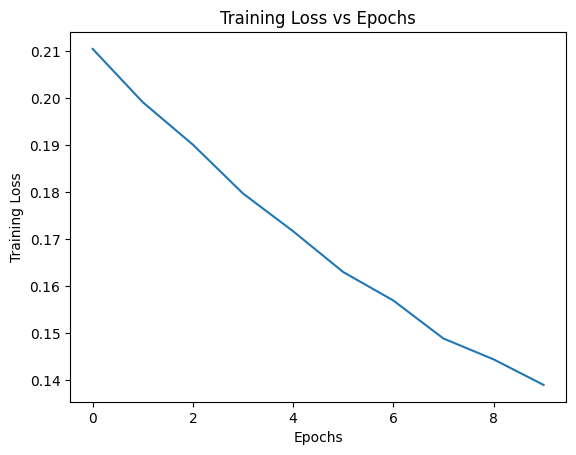

In [14]:
import matplotlib.pyplot as plt

plt.plot(losses)
plt.xlabel("Epochs")
plt.ylabel("Training Loss")
plt.title("Training Loss vs Epochs")
plt.show()


In [8]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = 100 * correct / total
print(f"Test Accuracy: {test_accuracy:.2f}%")


Test Accuracy: 87.94%


In the forward pass, the Fashion MNIST images are passed through the layers of the deep feedforward neural network to produce class score predictions.
The predicted outputs are compared with the true labels using the cross-entropy loss function to compute the training error.

The learning rate (0.001) controls the step size of weight updates; an appropriate learning rate ensures stable and efficient convergence, while a very high or very low value can cause unstable or slow training.
The batch size (64) determines how many training samples are processed before each weight update; smaller batch sizes improve generalization, whereas larger batch sizes reduce training time.
The number of epochs (10) defines how many times the entire training dataset is passed through the network; increasing epochs allows better learning, but too many epochs may lead to overfitting.